# This notebook will construct a baseline model to compare any other more complex model with

## Note: 
The baseline models to consider will be `LinearRegression` and `ElasticNet`. Using `LinearRegression` assumes that the features are linearly independent; however, as shown in the previous notebook, some features are correlated with each other, which violates this assumption. For this reason, `ElasticNet` is implemented, as its combined L1/L2 regularization mitigates the effect of multicollinearity. In addition to standard `ElasticNet`, which uses **coordinate descent** to optimize the weights, I will implement `SGDRegressor`, which fits an ElasticNet-style model but uses **stochastic gradient descent** instead. This allows me to train in epochs and batches, meaning I can update the model's weights online as new data arrives.

In [1]:
import numpy as np
import pandas as pd
import polars as pl
from pathlib import Path
from dataclasses import dataclass, asdict
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, ElasticNetCV
import warnings

# Configuration
These parameters come from the official documentation

In [2]:
# ============ RETURNS TO SIGNAL CONFIGS ============
MIN_SIGNAL: float = 0.0                         # Minimum value for the daily signal 
MAX_SIGNAL: float = 2.0                         # Maximum value for the daily signal 
SIGNAL_MULTIPLIER: float = 400.0                # Multiplier of the OLS market forward excess returns
                                                    #predictions to signal 

# Data classes helpers

In [3]:
@dataclass
class DatasetOutput:
    X_train: pl.DataFrame
    X_test: pl.DataFrame
    y_train: pl.Series
    y_test: pl.Series
    scaler: StandardScaler
    scaled: bool

    def __post_init__(self):
        '''Validates that each field holds the expected type, and that
        train/test splits are internally consistent.'''

        # --- type checks ---
        if not isinstance(self.X_train, pl.DataFrame):
            raise TypeError(
                f"X_train must be pl.DataFrame, got {type(self.X_train)}"
            )
        if not isinstance(self.X_test, pl.DataFrame):
            raise TypeError(
                f"X_test must be pl.DataFrame, got {type(self.X_test)}"
            )
        if not isinstance(self.y_train, pl.Series):
            raise TypeError(
                f"y_train must be pl.Series, got {type(self.y_train)}"
            )
        if not isinstance(self.y_test, pl.Series):
            raise TypeError(
                f"y_test must be pl.Series, got {type(self.y_test)}"
            )
        if not isinstance(self.scaler, StandardScaler):
            raise TypeError(
                f"scaler must be sklearn StandardScaler, got {type(self.scaler)}"
            )

        # --- shape / consistency checks ---
        if self.X_train.height != len(self.y_train):
            raise ValueError(
                f"X_train has {self.X_train.height} rows but y_train has "
                f"{len(self.y_train)} entries"
            )
        if self.X_test.height != len(self.y_test):
            raise ValueError(
                f"X_test has {self.X_test.height} rows but y_test has "
                f"{len(self.y_test)} entries"
            )
        if self.X_train.columns != self.X_test.columns:
            raise ValueError(
                f"X_train and X_test have mismatched columns: "
                f"{self.X_train.columns} vs {self.X_test.columns}"
            )

        # --- emptiness checks ---
        if self.X_train.height == 0:
            raise ValueError("X_train is empty")
        if self.X_test.height == 0:
            raise ValueError("X_test is empty")

        # --- scaler fitted check ---
        # A fitted StandardScaler has learned attributes ending in "_"
        # (mean_, scale_, var_). If they're absent, .fit() was never called.
        if not hasattr(self.scaler, "mean_"):
            warnings.warn(
                "scaler has not been fitted (missing 'mean_' attribute) — "
                "call scaler.fit(X_train) before constructing DatasetOutput"
            )

In [4]:
@dataclass 
class ElasticNetParameters:
    l1_ratio: np.ndarray
    cv: int
    alphas: np.ndarray
    max_iter: int

    def __post_init__(self):
        expected_types = {
            "l1_ratio": np.ndarray,
            "cv": int,
            "alphas": np.ndarray,
            "max_iter": int,
        }
        for name, expected in expected_types.items():
            value = getattr(self, name)
            if isinstance(value, bool) or not isinstance(value, expected):
                raise TypeError(f"{name} must be {expected}, got {type(value)}")

        #if not (0 <= self.l1_ratio <= 1):
        if np.max(self.l1_ratio)>1 or np.min(self.l1_ratio)<0:
            raise ValueError(f"l1_ratio must be in [0, 1], got {self.l1_ratio}")

In [5]:
@dataclass(frozen=True)
class RetToSignalParameters:
    signal_multiplier: float 
    min_signal : float = MIN_SIGNAL
    max_signal : float = MAX_SIGNAL

# Function helpers

In [6]:
def load_set(target_variable: str, file_name : str, n_exclude : int,
             shift_train_target: bool = False,) -> pl.DataFrame:
    """
    Loads and preprocesses the training dataset.
    Inputs:
    target_variable (str): variable that is the target of the predictions
    file_name (str) : the name of the file to be loaded
    n_exclude (int) : exclude the n last rows
    shift_train_target (bool): if True, shifts the target column up by
            one row, so that features at row t align with the target's
            value at row t+1, matching the feature/target alignment
            convention used in the test set. Defaults to False.
    
    Returns:
        pl.DataFrame: The preprocessed training DataFrame.
    """

    df = (pl.read_csv(DATA_PATH / file_name)
        .rename({target_variable:'target'})
        .with_columns(
            pl.exclude('date_id').cast(pl.Float64, strict=False) #cast to Float64 all columns except date
        )
        )
    total_exclude = max(n_exclude, 0)
    
    if shift_train_target:
        df = df.with_columns(pl.col("target").shift(-1).alias("target"))
        # the shift leaves the last row's target as null (no t+1 available);
        # fold that into the trailing-row exclusion so it's always dropped
        total_exclude += 1
        
    if total_exclude > 0:
        df = df.head(-total_exclude)
    return (df)


def split_dataset(train: pl.DataFrame, test: pl.DataFrame, features: list[str],
                 standard_scaler_bool: bool) -> DatasetOutput: 
    """
    Splits the data into features (X) and target (y), and scales the features.

    Args:
        train (pl.DataFrame): The processed training DataFrame.
        test (pl.DataFrame): The processed testing DataFrame.
        features (list[str]): List of features to used in model. 
        standard_scaler_bool (bool): Whether or not standard scaler is applied to the data.

    Returns:
        DatasetOutput: A dataclass containing the scaled feature sets, target series, and the fitted scaler.
    """
    # ========== For both, train and test, it drops date_id and target for the X features ===========
    # ========= and takes "target" for the Y (prediction) ===========================================
    X_train = train.drop(['date_id','target']) 
    y_train = train.get_column('target')
    
    X_test = test.drop(['date_id','target']) 
    y_test = test.get_column('target')

    if standard_scaler_bool:
        scaler = StandardScaler() 
        
        X_train_scaled_np = scaler.fit_transform(X_train)
        X_train = pl.from_numpy(X_train_scaled_np, schema=features)
        
        X_test_scaled_np = scaler.transform(X_test)
        X_test = pl.from_numpy(X_test_scaled_np, schema=features)
    else:
        scaler = StandardScaler() 
    
    
    return DatasetOutput(
        X_train = X_train,
        y_train = y_train, 
        X_test = X_test, 
        y_test = y_test,
        scaler = scaler,
        scaled = standard_scaler_bool,
    )

# Reading input data

In [7]:
DATA_PATH = Path("/kaggle/input/notebooks/sebastianvpal/data-exploration")
path_train = ("train_split.csv")
path_test = ("test_split.csv")
path_val = ("val_split.csv")

# ============ Reading data
target_variable_training = 'market_forward_excess_returns'
target_variable_test_val = 'lagged_forward_returns'
#===========
ds_train = load_set(target_variable=target_variable_training, 
                    file_name = path_train, n_exclude = 10, shift_train_target=True)
                        # align features(t) -> target(t+1), matching test set) 
#===========
ds_test = load_set(target_variable=target_variable_test_val, 
                    file_name = path_test, n_exclude=0) 
#===========
ds_val = load_set(target_variable=target_variable_test_val, 
                    file_name = path_val, n_exclude=0) 

In [8]:
raw = pl.read_csv(DATA_PATH / path_train).rename({target_variable_training: "target"})
shifted = raw.with_columns(pl.col("target").shift(-1).alias("target_shifted"))

print(shifted.select(["date_id", "target", "target_shifted"]).head(5))

shape: (5, 3)
┌─────────┬───────────┬────────────────┐
│ date_id ┆ target    ┆ target_shifted │
│ ---     ┆ ---       ┆ ---            │
│ i64     ┆ f64       ┆ f64            │
╞═════════╪═══════════╪════════════════╡
│ 0       ┆ -0.003038 ┆ -0.009114      │
│ 1       ┆ -0.009114 ┆ -0.010243      │
│ 2       ┆ -0.010243 ┆ 0.004046       │
│ 3       ┆ 0.004046  ┆ -0.012301      │
│ 4       ┆ -0.012301 ┆ -0.007066      │
└─────────┴───────────┴────────────────┘


In [9]:
ds_train.head()

date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,target
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.002421,0.000301,-0.009114
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.008495,0.000303,-0.010243
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.009624,0.000301,0.004046
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.004662,0.000299,-0.012301
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.011686,0.000299,-0.007066


In [10]:
ds_val.head()

date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,lagged_risk_free_rate,lagged_market_forward_excess_returns,target
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
7239,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.990624,0.365741,0.001653,0.001653,0.001653,0.001653,0.04795,1.581325,2.093015,1.379707,-0.71679,2.092084,2.807998,1.793679,0.006283,0.779101,0.029431,1.896672,-1.796922,0.018849,0.146164,0.2890181,0.957011,0.47619,2.771271,0.943783,0.13955,…,0.657407,-1.819954,0.775463,0.332011,-0.178183,-0.339824,-0.828422,2.006619,0.061508,1.101647,0.102513,0.21627,-1.247254,0.103221,0.806193,0.369048,-0.025806,0.594577,0.665675,0.738447,0.148148,0.544974,-0.804609,0.499008,0.511243,-0.350953,0.236772,0.708995,0.546296,1.557415,0.021825,-0.654966,0.939153,-0.563655,0.000084,-0.003715,-0.003322
7240,1.0,1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.989649,0.366071,0.001323,0.001323,0.001323,0.001323,0.047619,1.579459,2.088681,1.377822,-0.87895,2.06872,2.80011,1.759865,0.005952,0.779431,0.029101,1.89336,-1.795177,0.018519,0.103175,0.343596,0.95172,0.510582,2.835984,0.945106,0.128968,…,0.510913,-1.733356,0.225198,0.979497,-0.838253,-0.208185,-0.047079,2.001718,0.060847,1.142233,0.517857,0.531746,0.030527,0.24841,0.771682,0.297619,-0.055489,0.594246,0.666005,0.759988,0.118386,0.478175,-0.766743,0.539683,0.484788,-0.270431,0.210979,0.552249,0.54828,1.22139,0.23545,-0.594589,0.957341,-0.511733,0.000084,-0.001321,-0.000928
7241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.9886771,0.366402,0.000992,0.000992,0.000992,0.000992,0.047288,1.5776,2.084368,1.375941,-0.11586,2.020403,2.792283,1.686782,0.005622,0.779762,0.02877,1.910961,-1.793444,0.018188,0.102844,0.3707656,0.928571,0.47586,2.813473,0.946429,0.094577,…,0.83631,-1.738171,0.7093254,0.2146164,-0.542606,-0.09852,-0.458369,1.992025,0.058532,1.279896,0.467593,0.271825,-0.299065,0.106096,0.732142,0.320106,-0.020315,0.593915,0.666336,0.710854,0.036376,0.387566,-0.70436,0.541997,0.412368,-0.157248,0.19246,0.687169,0.472884,1.07712,0.425926,-0.466165,0.922619,-0.432432,0.000086,-0.003387,-0.002992
7242,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.987708,0.366733,0.000661,0.000661,0.000661,0.000661,0.046958,1.575748,2.080076,1.374065,-0.756943,2.048743,2.789941,1.734173,0.005291,0.780093,0.028439,1.356151,-1.507286,0.017857,0.065476,0.2885933,0.922619,0.50959,2.771646,0.951058,0.070106,…,0.542659,-1.61525,0.443452,0.955026,-0.754065,0.044004,0.5087919,2.002054,0.050265,1.333218,0.71164,0.695767,0.26913,0.035439,0.660298,0.437831,-0.093189,0.588624,0.666667,0.721815,0.044974,0.444444,-0.756598,0.681878,0.660053,-0.282641,0.434524,0.64418,0.568122,1.482078,0.31746,-0.596701,0.95172,-0.521192,0.000086,0.0024,0.002794
7243,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.986742,0.367063,0.006944,0.006944,0.006944,0.006944,0.046627,1.573903,2.075804,1.372193,-0.512284,2.042226,2.7779029,1.726744,0.00496,0.780423,0.028108,1.170102,-1.506086,0.017526,0.043651,0.2610075,0.920635,0.475529,2.778965,0.963624,0.046296,…,0.572421,-1.732932,0.069114,0.473876,-0.95372,0.2743373,0.6159671,2.001656,0.048942,1.373274,0.005952,0.10119,-0.12671,-0.1074,0.629424,0.205688,-0.233184,0.46164,0.666997,0.632255,0.590608,0.648148,-0.792361,0.795304,0.723545,-0.362596,0.48082,0.607804,0.588624,1.617606,0.301587,-0.6751,0.962302,-0.561684,0.000085,-0.000291,0.000103


According to the official documentation `forward_returns` and `risk_free_rate`are not available for the test dataset (train set only) I will drop these columns for this baseline model(s).

In [11]:
features_to_drop_train = ["forward_returns", "risk_free_rate"]
features_to_drop_test_val = ["lagged_risk_free_rate", "lagged_market_forward_excess_returns"]

ds_train = ds_train.drop(features_to_drop_train)
ds_test = ds_test.drop(features_to_drop_test_val)
ds_val = ds_val.drop(features_to_drop_test_val)

In [12]:
ds_train.head()

date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P11,P12,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,target
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.009114
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.010243
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.004046
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.012301
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.007066


In [13]:
ds_test.head()

date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P11,P12,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,target
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8143,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.2657731,0.78836,0.006944,0.006944,0.006944,0.006944,0.415675,-0.564497,0.3004954,1.623869,1.252339,0.499862,2.785689,0.598775,0.00496,0.107143,0.021825,-0.233085,-0.382188,0.223214,0.647487,1.130421,0.251323,0.37004,-0.146212,0.607143,0.492063,…,1.388739,-0.730158,0.38955,-1.265806,0.799603,0.44213,-1.320156,1.886526,0.066089,2.345816,0.068783,1.044971,0.064153,0.058862,-0.049095,-1.012696,-1.369763,0.161376,3.285874,0.640542,0.563492,-2.17246,0.041005,0.441138,1.644329,0.383267,0.082672,2.006571,0.311508,0.421296,0.39881,0.4314503,0.19246,1.58607,0.560516,1.593751,0.002812
8144,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.2640387,0.78869,0.006614,0.006614,0.006614,0.006614,0.416005,-0.564062,0.299804,1.62123,0.9611895,0.685653,2.755798,0.830465,0.00463,0.106812,0.021495,-0.233069,-0.387415,0.222884,0.583664,1.197944,0.290344,0.37037,-0.17395,0.612434,0.475529,…,1.518543,-0.103053,0.500661,-1.379897,0.465608,0.933532,-1.216229,2.018084,2.122691,2.571403,0.045635,1.018484,0.231481,0.071429,-1.078241,-1.146821,-1.467586,0.227513,2.021645,0.640873,0.563161,-2.344621,0.085979,0.424603,1.539259,0.492063,0.184854,1.583708,0.455026,0.53836,0.431878,0.4946664,0.178571,1.392011,0.585979,1.450365,0.025259
8145,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.262308,0.789021,0.006283,0.006283,0.006283,0.006283,0.355489,-0.563627,0.2991125,1.618598,1.068646,0.39593,2.761082,0.476752,0.004299,0.106481,0.021164,-0.093575,-0.387338,0.222553,0.626653,1.265185,0.279101,0.370701,-0.14717,0.642857,0.48082,…,1.316646,0.304379,0.390542,-1.164048,0.047619,0.748677,-1.141425,1.763093,-1.441855,2.19355,0.033069,1.01828,0.298942,0.166667,-0.657863,-1.009937,-1.544312,0.421296,2.663011,0.361442,0.562831,-2.339564,0.650794,0.536376,1.745958,0.507606,0.298942,2.398428,0.475529,0.632937,0.445767,0.3255986,0.213624,1.795219,0.60119,1.720207,-0.036956
8146,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.2605808,0.85582,0.005952,0.005952,0.005952,0.005952,0.35582,-0.601055,-0.066242,1.437876,2.216186,0.434836,2.766712,0.526861,0.003968,0.106151,0.020833,-0.118378,-0.387262,0.222222,0.626323,1.315382,0.253968,0.337632,-0.198687,0.634921,0.498016,…,1.348803,-0.521758,0.095899,-1.223703,0.793981,0.287037,-1.169492,1.07472,-0.194556,2.27641,0.051587,1.016935,0.406085,0.356481,-0.127514,-1.211736,-1.686039,0.521825,2.606319,0.361772,0.704034,-2.543704,0.582011,0.570106,1.744461,0.448082,0.229167,1.906244,0.455026,0.417989,0.453042,0.357845,0.269841,1.666204,0.587963,1.694512,0.006019
8147,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.2588571,0.856151,0.005622,0.005622,0.005622,0.005622,0.356151,-0.600582,-0.066768,1.43574,1.272444,0.467547,2.788191,0.569349,0.003638,0.10582,0.020503,-0.120138,-0.387186,0.221892,0.669312,1.534169,0.214286,0.371032,-0.044973,0.632275,0.46164,…,1.373746,-0.521305,0.305225,-1.249651,0.047288,0.5515873,-1.212364,2.018503,1.396727,2.33757,0.030423,1.024718,0.029101,0.036376,-0.517334,-1.480639,-1.683436,0.127646,1.763519,0.259921,0.704365,-2.54303,0.873016,0.479497,1.479434,0.529431,0.296296,1.111741,0.51918,0.659392,0.492063,-0.154734,0.347884,1.296785,0.606481,1.397382,0.004584


# Generating training and test dataset

In [14]:
# creating list of features
FEATURES: list[str] = [col for col in ds_train.columns if col not in ['date_id', 'target']]

# creating the dataset. This data will be used for ElasticNet, so standardscaler is needed
dataset: DatasetOutput = split_dataset(train=ds_train, test=ds_test, features=FEATURES,
                                      standard_scaler_bool= True) 

X_train: pl.DataFrame = dataset.X_train
X_test: pl.DataFrame = dataset.X_test
y_train: pl.DataFrame = dataset.y_train
y_test: pl.DataFrame = dataset.y_test
scaler: StandardScaler = dataset.scaler 
scaled: bool = dataset.scaled

In [15]:
print(f"values were scaled: {scaled}")

values were scaled: True


**Given the amount of missing value and its position in the dataset (check data_exploration notebook) I will do imputation of the missing values adding a 0 and a new column 1:real data, 0: artificial, so the model can also distinguish from a real or imputed 0**

In [16]:
imputer = SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Grid-search using ElasticNetCV

In [17]:
# ============ MODEL CONFIGS ============
CV: int = 10                                   # Number of cross validation folds in the model fitting
L1_RATIO: float = np.array([0.1, 0.25, 0.4, 0.55, 0.7, 0.76, 0.82, 0.88, 0.94, 1.])                          # ElasticNet mixing parameter
ALPHAS: np.ndarray = np.logspace(-3, 2, 100)    # Constant that multiplies the penalty terms
MAX_ITER: int = 10_000                         # The maximum number of iterations in coordinate descent

In [18]:
enet_params = ElasticNetParameters(
    l1_ratio = L1_RATIO, 
    cv = CV, 
    alphas = ALPHAS, 
    max_iter = MAX_ITER
)

In [19]:
model_cv: ElasticNetCV = ElasticNetCV(**asdict(enet_params))
model_cv.fit(X_train, y_train) 
        




ElasticNetCV(alphas=array([1.00000000e-03, 1.12332403e-03, 1.26185688e-03, 1.41747416e-03,
       1.59228279e-03, 1.78864953e-03, 2.00923300e-03, 2.25701972e-03,
       2.53536449e-03, 2.84803587e-03, 3.19926714e-03, 3.59381366e-03,
       4.03701726e-03, 4.53487851e-03, 5.09413801e-03, 5.72236766e-03,
       6.42807312e-03, 7.22080902e-03, 8.11130831e-03, 9.11162756e-03,
       1.02353102e-02, 1.149757...
       1.09749877e+01, 1.23284674e+01, 1.38488637e+01, 1.55567614e+01,
       1.74752840e+01, 1.96304065e+01, 2.20513074e+01, 2.47707636e+01,
       2.78255940e+01, 3.12571585e+01, 3.51119173e+01, 3.94420606e+01,
       4.43062146e+01, 4.97702356e+01, 5.59081018e+01, 6.28029144e+01,
       7.05480231e+01, 7.92482898e+01, 8.90215085e+01, 1.00000000e+02]),
             cv=10,
             l1_ratio=array([0.1 , 0.25, 0.4 , 0.55, 0.7 , 0.76, 0.82, 0.88, 0.94, 1.  ]),
             max_iter=10000)

In [20]:
print(f"CV for ElasticNet give as optimal alpha and l1_ratio values: {model_cv.alpha_}, {model_cv.l1_ratio_}, respectively")

CV for ElasticNet give as optimal alpha and l1_ratio values: 0.002009233002565048, 0.1, respectively


# Fit the final model using the best alpha found by cross-validation

In [21]:
model: ElasticNet = ElasticNet(alpha=model_cv.alpha_, l1_ratio=model_cv.l1_ratio_) 
model.fit(X_train, y_train)

ElasticNet(alpha=np.float64(0.002009233002565048), l1_ratio=np.float64(0.1))

# Metrics on the test set with the model

In [22]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [23]:
y_pred = model.predict(X_test) #Making predictions

# Evaluating predictions
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Selected alpha: {model_cv.alpha_:.5g}")
print("==============================================")
print(f"Selected l1_ratio: {model_cv.l1_ratio_:.3f}")
print("==============================================")
print(f"Test R²:   {r2:.4f}")
print("==============================================")
print(f"max(y_pred): {y_pred.max():.6f}")
print(f"max(y_test): {y_test.max():.6f}")
print("==============================================")
print(f"min(y_pred): {y_pred.min():.6f}")
print(f"min(y_test): {y_test.min():.6f}")
print("==============================================")
print(f"Test RMSE: {rmse:.4f}")
print("==============================================")
print(f"Test MAE:  {mae:.4f}")

Selected alpha: 0.0020092
Selected l1_ratio: 0.100
Test R²:   -0.0321
max(y_pred): 0.002186
max(y_test): 0.040661
min(y_pred): -0.003041
min(y_test): -0.039754
Test RMSE: 0.0107
Test MAE:  0.0077


In [24]:
y_train.max()

0.04005815

In [25]:
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

print(f"max(y_train): {y_train.max():.6f}")
print(f"max(y_test): {y_test.max():.6f}")
print("==============================================")
print(f"min(y_train): {y_train_np.min():.6f}")
print(f"min(y_test): {y_test_np.min():.6f}")
print("==============================================")
print(f"Var(y_train): {np.var(y_train_np):.6f}")
print(f"Var(y_test):  {np.var(y_test_np):.6f}")
print("==============================================")
print(f"Mean(y_train): {np.mean(y_train_np):.6f}")
print(f"Mean(y_test):  {np.mean(y_test_np):.6f}")
print("==============================================")
print(f"MSE (model):  {rmse**2:.6f}")
print("==============================================")
# What R² would be if you just predicted the train mean for every test point:
naive_pred = np.full_like(y_test_np, fill_value=np.mean(y_train_np))
naive_r2 = r2_score(y_test_np, naive_pred)
print(f"Naive (train-mean) baseline R²: {naive_r2:.4f}")

max(y_train): 0.040058
max(y_test): 0.040661
min(y_train): -0.039942
min(y_test): -0.039754
Var(y_train): 0.000108
Var(y_test):  0.000110
Mean(y_train): 0.000015
Mean(y_test):  0.000610
MSE (model):  0.000114
Naive (train-mean) baseline R²: -0.0032


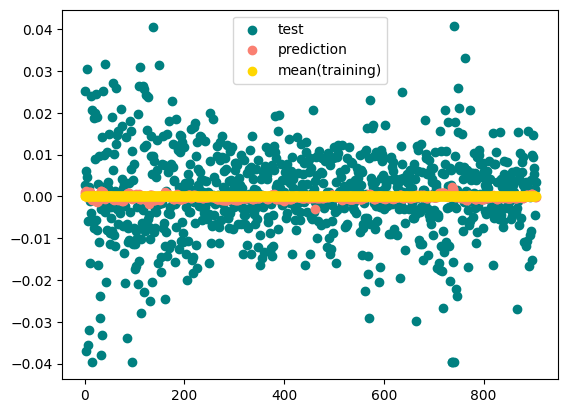

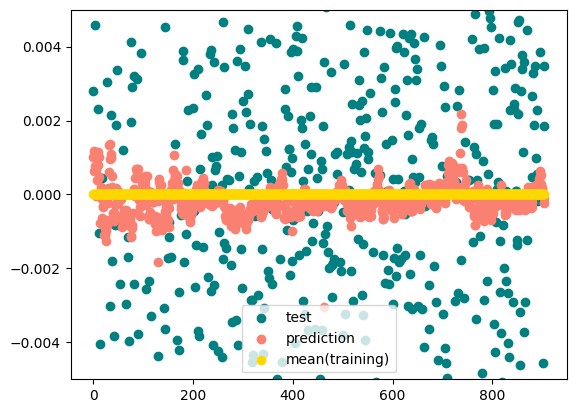

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')

plt.legend()
plt.show()
#============ plot with zoom =============0
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')
ax.set_ylim(-0.005,0.005)
plt.legend()
plt.show()

**Observations**
1. The model R$^2$ is -0.0678. A R$^2$ =1 tells us that the model makes a perfect prediction of the data, a R$^2$ = 0 it means that the model has a prediction power equivalent to only use the mean of the data and a R$^2$ < 0 means that the model predicts worst than by using the mean. For example, when the mean of the trainin data was used to compute the predictions, an R$^2$ = -0.0032, which is almost 2 times larger than with the ElasticNet model.
2. A RMSE of 0.0108 with test data in the range [-0.039,0,040] shows a considerably error given the scale of the data
3. A MAE of 0.0079 corresponds to roughly 75% of the standard deviation of the test target (
σytest≈0.0105, indicating that the model's typical prediction error is comparable in size to the natural variability of the data itself — consistent with a model that carries little linearly-exploitable signal beyond the mean. The RMSE-to-MAE ratio of ≈1.37 further suggests the error is not uniform: a subset of predictions (likely those corresponding to the more extreme test values, which fall outside the model's narrow predicted range per point 4) contribute disproportionately large residuals.
4. The above Figure also shows what the previous statistics present; the model  is able to predict within a very narrow windows of values and it struggles to capture the behavior of the test data beyon its mean value.

# walk-forward (rolling-window) online training

In [27]:
from sklearn.linear_model import SGDRegressor

In [28]:
def walk_forward_SGD(X:pl.DataFrame, y:pl.Series, window_size:int,
                    step_size:int, eval_size:int, sgd_params:dict | None=None)->pl.DataFrame:
    """
    Simulates online learning: slides a training window across the data,
    incrementally updates an SGDRegressor via partial_fit, evaluates on
    the immediately following block, then advances.

    Args:
        X: full feature set, in chronological order.
        y: full target, in chronological order, aligned with X.
        window_size: number of samples in each training window.
        step_size: how far to slide the window forward each iteration.
        eval_size: number of samples immediately after the window to
            evaluate on (out-of-sample, "future" relative to that window).
        sgd_params: kwargs passed to SGDRegressor.

    Returns:
        pl.DataFrame with one row per step: window bounds and eval metrics.
    """
    sgd_params = sgd_params or {}
    if isinstance(X, pl.DataFrame):
        n = X.height
        X_np = X.to_numpy()
    elif isinstance(X, np.ndarray):
        n = len(X)
        X_np = X
    else:
        raise TypeError(f"X must be pl.DataFrame or np.ndarray, got {type(X)}")

    #print(f"Number of samples in training dataset, n: {n}")
    
    if isinstance(y, pl.Series):
        y_np = y.to_numpy()
    elif isinstance(y, np.ndarray):
        y_np = y
    else:
        raise TypeError(f"y must be pl.Series or np.ndarray, got {type(y)}")
    
    

    # warm_start=True is essential: without it, calling .fit() again would
    # reset weigths; partial_fit always updates in place regardless
    #model = SGDRegressor(loss="squared_error", penalty="elasticnet",warm_start=True, **sgd_params)
    default_sgd_params = {
        "loss": "squared_error",
        "penalty": "elasticnet",
        "warm_start": True,
    }
    sgd_params = {**default_sgd_params, **(sgd_params or {})}
    model = SGDRegressor(**sgd_params)
    scaler = StandardScaler()

    results = []
    start = 0

    while start+window_size+eval_size <= n: #I haven't exceed the number of samples
        train_idx = slice(start,start+window_size)
        eval_idx = slice(start+window_size,start+window_size+eval_size)
        #======= selecting training data for that window ==================
        X_train_w = X_np[train_idx]
        y_train_w = y_np[train_idx]
        #======= selecting evaluation data for that window ==================
        X_eval_w = X_np[eval_idx]
        y_eval_w = y_np[eval_idx]

        #======== online scaling: update running statistics with this window only,
        #      then transform using stats known up to this point =================
        scaler.partial_fit(X_train_w)
        X_train_scaled = scaler.transform(X_train_w)
        X_eval_scaled = scaler.transform(X_eval_w)

        # ======= Incremental model update in this window ===========
        model.partial_fit(X_train_scaled, y_train_w)

        # ======= Evaluate on the immediately following (unseen) block =====
        y_pred = model.predict(X_eval_scaled)

        results.append({"train_start":start,
                       "train_end": start+window_size,
                       "eval_start":start+window_size,
                        "eval_end": start+window_size+eval_size,
                       "r2": r2_score(y_eval_w, y_pred),
                       "rmse": np.sqrt(mean_squared_error(y_eval_w, y_pred)),
                       "mae": mean_absolute_error(y_eval_w, y_pred),
                       "y_pred": y_pred,
                       "y_eval":y_eval_w})
        start += step_size

    return pl.DataFrame(results)

In [29]:
import itertools
import numpy as np
import polars as pl

def grid_search_walk_forward(
    X, y,
    window_size_options: list[int],
    step_size_options: list[int],
    eval_size_options: list[int],
    sgd_param_grid: dict[str, list],
) -> pl.DataFrame:
    """
    Runs walk_forward_sgd across a grid of window/step/eval sizes and
    SGDRegressor hyperparameters, returning one row per combination with
    an aggregate (pooled) R² across all windows in that run.

    Args:
        X, y: full chronologically-ordered features/target.
        window_size_options, step_size_options, eval_size_options: lists
            of candidate values for the walk-forward schedule.
        sgd_param_grid: dict mapping SGDRegressor kwarg name -> list of
            candidate values, e.g. {"alpha": [1e-4, 1e-3], "eta0": [0.001, 0.01]}.

    Returns:
        pl.DataFrame, one row per combination, sorted by pooled_r2 descending.
    """
    # cartesian product over the schedule params
    schedule_grid = list(itertools.product(
        window_size_options, step_size_options, eval_size_options
    ))

    # cartesian product over sgd_params (keeps other fixed kwargs untouched)
    sgd_keys = list(sgd_param_grid.keys())
    sgd_value_combos = list(itertools.product(*sgd_param_grid.values()))

    records = []

    for window_size, step_size, eval_size in schedule_grid:
        for combo in sgd_value_combos:
            sgd_params = dict(zip(sgd_keys, combo))
            # merge with any fixed defaults you always want
            full_sgd_params = {
                "loss": "squared_error",
                "penalty": "elasticnet",
                "warm_start": True,
                "max_iter": 1,
                "tol": None,
                "learning_rate": "invscaling",
                "random_state": 0,
                **sgd_params,   # overrides defaults with grid values
            }

            try:
                results = walk_forward_SGD(
                    X=X, y=y,
                    window_size=window_size,
                    step_size=step_size,
                    eval_size=eval_size,
                    sgd_params=full_sgd_params,
                )
            except Exception as e:
                # some combinations (e.g. window_size too large for len(X))
                # may be infeasible — skip rather than crash the whole search
                records.append({
                    "window_size": window_size, "step_size": step_size,
                    "eval_size": eval_size, **sgd_params,
                    "pooled_r2": np.nan, "mean_window_r2": np.nan,
                    "error": str(e),
                })
                continue

            pooled_r2 = results["r2"].mean()  # or compute pooled metric, see note below
            records.append({
                "window_size": window_size,
                "step_size": step_size,
                "eval_size": eval_size,
                **sgd_params,
                "mean_window_r2": results["r2"].mean(),
                "mean_window_rmse": results["rmse"].mean(),
                "n_windows": results.height,
                "error": None,
            })

    grid_results = pl.DataFrame(records)
    return grid_results.sort("mean_window_r2", descending=True)

**Note:** In this case the StandardScaler is **NOT** applyied as this will be done online as the data is streamed 

In [30]:
# creating list of features
FEATURES: list[str] = [col for col in ds_train.columns if col not in ['date_id', 'target']]

# creating the dataset. This data will be used for ElasticNet, so standardscaler is needed
dataset: DatasetOutput = split_dataset(train=ds_train, test=ds_test, features=FEATURES,
                                      standard_scaler_bool= False) 

X_train: pl.DataFrame = dataset.X_train
X_test: pl.DataFrame = dataset.X_test
y_train: pl.DataFrame = dataset.y_train
y_test: pl.DataFrame = dataset.y_test
scaler: StandardScaler = dataset.scaler 
scaled: bool = dataset.scaled

# ======== Applying inputer ==================
imputer = SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

/tmp/ipykernel_58/1883765255.py:63: UserWarning: scaler has not been fitted (missing 'mean_' attribute) — call scaler.fit(X_train) before constructing DatasetOutput
  warnings.warn(


In [31]:
grid_results = grid_search_walk_forward(
    X=X_train, y=y_train,
    window_size_options=[500, 1000, 2000],
    step_size_options=[50, 100],
    eval_size_options=[50, 100],
    sgd_param_grid={
        "alpha": [1e-4, 1e-3, 1e-2],
        "l1_ratio": [0.1, 0.5, 0.9],
        "eta0": [0.001, 0.01, 0.1],
    },
)

print(grid_results.head(10))
best_config = grid_results.row(0, named=True)
print("Best config:", best_config)

shape: (10, 10)
┌─────────────┬───────────┬───────────┬───────┬───┬──────────────┬─────────────┬───────────┬───────┐
│ window_size ┆ step_size ┆ eval_size ┆ alpha ┆ … ┆ mean_window_ ┆ mean_window ┆ n_windows ┆ error │
│ ---         ┆ ---       ┆ ---       ┆ ---   ┆   ┆ r2           ┆ _rmse       ┆ ---       ┆ ---   │
│ i64         ┆ i64       ┆ i64       ┆ f64   ┆   ┆ ---          ┆ ---         ┆ i64       ┆ null  │
│             ┆           ┆           ┆       ┆   ┆ f64          ┆ f64         ┆           ┆       │
╞═════════════╪═══════════╪═══════════╪═══════╪═══╪══════════════╪═════════════╪═══════════╪═══════╡
│ 500         ┆ 100       ┆ 100       ┆ 0.01  ┆ … ┆ -0.005972    ┆ 0.009648    ┆ 67        ┆ null  │
│ 500         ┆ 100       ┆ 100       ┆ 0.01  ┆ … ┆ -0.006012    ┆ 0.009648    ┆ 67        ┆ null  │
│ 2000        ┆ 100       ┆ 100       ┆ 0.01  ┆ … ┆ -0.006196    ┆ 0.010352    ┆ 52        ┆ null  │
│ 2000        ┆ 100       ┆ 100       ┆ 0.01  ┆ … ┆ -0.00621     ┆ 0.010352

In [32]:
results = walk_forward_SGD(
    X = X_train,
    y = y_train,
    window_size = 500, #train of 200 samples at the time
    step_size = 100,    #slide forward by 50 samples each step
    eval_size = 100,    #evaluate on the next 50 samples
    sgd_params={"alpha":0.01,"l1_ratio":0.5,"max_iter":1,#max_iter with .partial_fit is ignored
               "tol":None, "learning_rate":"invscaling","eta0":0.001, "random_state":0}
)#"eta0" is the value used in the learning_rate equation in SGD, 

In [33]:
results

train_start,train_end,eval_start,eval_end,r2,rmse,mae,y_pred,y_eval
i64,i64,i64,i64,f64,f64,f64,list[f64],list[f64]
0,500,500,600,-0.000018,0.007048,0.005331,"[-0.000018, -0.000018, … -0.000018]","[0.013471, 0.003646, … 0.006319]"
100,600,600,700,-0.004511,0.006005,0.004532,"[-0.000022, -0.000022, … -0.000022]","[0.008265, -0.002688, … 0.008377]"
200,700,700,800,-0.011696,0.005716,0.004154,"[0.000002, 0.000002, … 0.000002]","[-0.012817, 0.0115923, … 0.003745]"
300,800,800,900,-0.002722,0.006348,0.004685,"[0.000006, 0.000006, … 0.000006]","[-0.005967, -0.003211, … 0.005158]"
400,900,900,1000,-0.00006,0.004396,0.003339,"[0.000004, 0.000004, … 0.000004]","[-0.001128, -0.002518, … -0.001774]"
…,…,…,…,…,…,…,…,…
6200,6700,6700,6800,-0.001251,0.005955,0.004275,"[0.00004, 0.00004, … 0.00004]","[0.007863, -0.000914, … 0.002153]"
6300,6800,6800,6900,-0.002957,0.004599,0.003378,"[0.000039, 0.000039, … 0.000039]","[-0.008592, -0.00055, … 0.004734]"
6400,6900,6900,7000,-0.006181,0.004233,0.00282,"[0.00004, 0.00004, … 0.00004]","[0.00187, 0.00199, … -0.001841]"


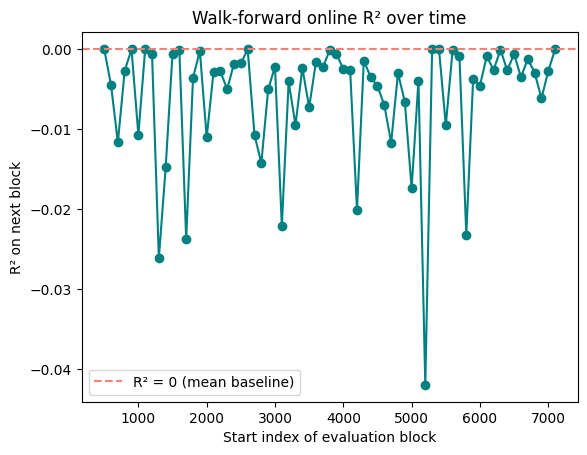

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(results["eval_start"], results["r2"], marker="o", color="teal")
ax.axhline(0, color="salmon", linestyle="--", label="R² = 0 (mean baseline)")
ax.set_xlabel("Start index of evaluation block")
ax.set_ylabel("R² on next block")
ax.set_title("Walk-forward online R² over time")
ax.legend()
plt.show()

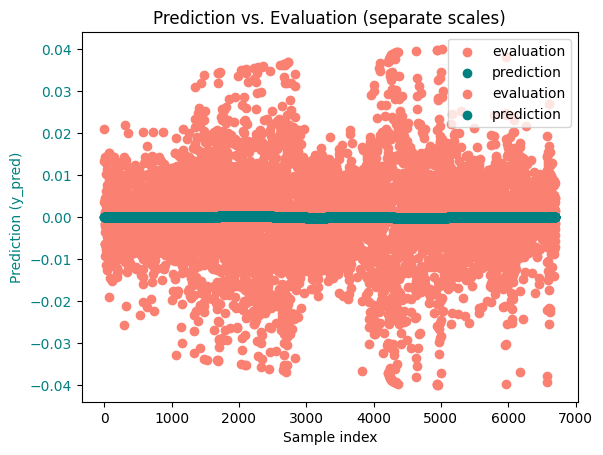

In [35]:
fig, ax1 = plt.subplots()

y_pred_in = results["y_pred"].explode()
y_eval_in = results["y_eval"].explode()

x_plot_in = np.arange(len(y_pred_in))

ax2 = ax1#.twinx()

ax1.scatter(x_plot_in, y_eval_in, label="evaluation", color="salmon")
ax2.scatter(x_plot_in, y_pred_in, label="prediction", color="teal")

ax1.set_ylabel("Evaluation (y_true)", color="salmon")
ax2.set_ylabel("Prediction (y_pred)", color="teal")
ax1.tick_params(axis="y", labelcolor="salmon")
ax2.tick_params(axis="y", labelcolor="teal")
ax1.set_xlabel("Sample index")

# combine legends from both axes into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Prediction vs. Evaluation (separate scales)")
plt.show()

# Conclusions:
These two linear models, i.e. ElasticNet and SGDRegressor, are unable to predict the target variable with any meaningful accuracy. Their predictive performance is worse than simply using the training set's mean value as the forecast for every point (test R² of −0.068 for ElasticNet, compared to −0.003 for the naive mean baseline). This is due in part to the models under-predicting the target's variability: rather than reproducing the wide fluctuations characteristic of the market data, both models collapse toward a narrow range of values close to the mean, failing to capture the larger deviations present in the true target. It is not surprising that the two models perform similarly, since both are fundamentally solving the same linear problem — the main difference lies in how they are trained. ElasticNet has access to the entire training set at once, whereas SGDRegressor is trained incrementally on a sliding window of data, mimicking how a deployed model would behave as new data arrives and its weights are refined over time.